In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_comercial = pd.read_csv('/content/fashion_returns_master.csv')
df_comercial.head()

,order_id,marketplace_region,category,fabric,price_usd,discount_pct,is_premium,size_ordered,size_usual,size_mismatch,...,num_reviews,reviews_read,size_chart_viewed,model_shown,is_gift,device,days_to_delivery,return_shipping_free,return_reason,returned
0,ORD000000,FR,shoes,silk,183.72,30,1,0,0,0,...,111,0,1,1,0,desktop,5,0,not_returned,0
1,ORD000001,NL,dress,denim,96.76,30,0,6,6,0,...,119,1,1,1,0,mobile,10,1,poor_fit,1
2,ORD000002,IT,dress,denim,217.00,10,1,4,2,2,...,121,0,0,1,0,desktop,5,1,size_too_large,1
3,ORD000003,US,dress,polyester,92.73,20,0,3,1,2,...,108,1,1,1,0,mobile,1,0,quality_defect,1
4,ORD000004,ES,accessories,jersey,41.97,30,0,3,2,1,...,143,0,1,1,0,mobile,5,1,not_returned,0


Features Numéricas (17): ['price_usd', 'discount_pct', 'is_premium', 'size_ordered', 'size_usual', 'size_mismatch', 'ordered_multiple_sizes', 'customer_prior_orders', 'customer_prior_return_rate', 'avg_review_rating', 'num_reviews', 'reviews_read', 'size_chart_viewed', 'model_shown', 'is_gift', 'days_to_delivery', 'return_shipping_free']
Features Categóricas (5): ['marketplace_region', 'category', 'fabric', 'fit_type', 'device']

--- RELATÓRIO DE DESEMPENHO ---
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      7187
           1       0.72      0.50      0.59      2813

    accuracy                           0.80     10000
   macro avg       0.77      0.71      0.73     10000
weighted avg       0.79      0.80      0.79     10000

ROC-AUC Score: 0.8366


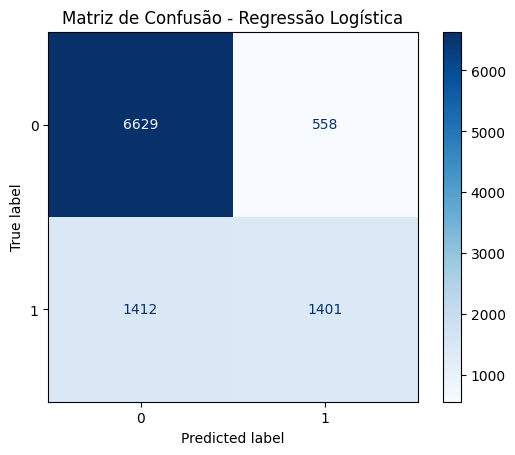

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Separar X (features) e y (target) descartando colunas de identificação e vazamento
X = df_comercial.drop(columns=['returned', 'return_reason', 'order_id'])
y = df_comercial['returned']

# 2. Identificar automaticamente colunas numéricas e categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features Numéricas ({len(num_cols)}): {num_cols}")
print(f"Features Categóricas ({len(cat_cols)}): {cat_cols}")

# 3. Criar o pré-processador (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# 4. Criar a Pipeline com Regressão Logística
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

# 5. Dividir em Treino (80%) e Teste (20%) mantendo a proporção de classe (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Treinar o modelo
model_pipeline.fit(X_train, y_train)

# 7. Prever no conjunto de teste
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# 8. Avaliar os Resultados
print("\n--- RELATÓRIO DE DESEMPENHO ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Plota a Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

=== REGRESSÃO LOGÍSTICA (Threshold Ajustado: 35%) ===
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      7187
           1       0.61      0.66      0.64      2813

    accuracy                           0.79     10000
   macro avg       0.74      0.75      0.74     10000
weighted avg       0.79      0.79      0.79     10000



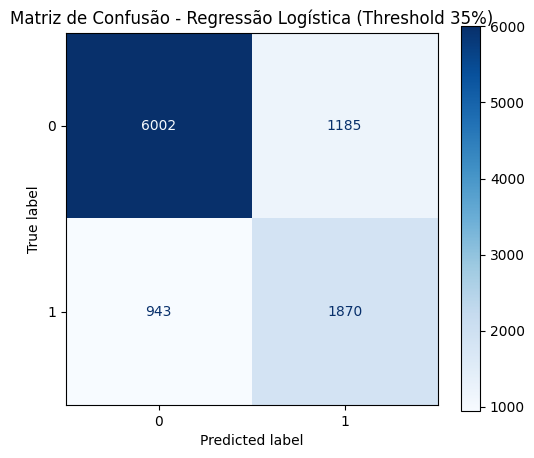


=== TOP 5 FATORES QUE AUMENTAM A CHANCE DE DEVOLUÇÃO ===
               Feature  Coeficiente  Odds_Ratio
cat__category_trousers     1.287777    3.624719
   cat__category_jeans     1.273082    3.571845
   cat__category_shoes     1.206393    3.341410
   cat__category_dress     1.195287    3.304505
    num__size_mismatch     1.068431    2.910807

=== TOP 5 FATORES QUE REDUZEM A CHANCE DE DEVOLUÇÃO ===
                   Feature  Coeficiente  Odds_Ratio
        cat__fabric_jersey    -0.137912    0.871176
cat__fabric_cotton_stretch    -0.223778    0.799493
     cat__fit_type_regular    -0.224384    0.799008
    num__avg_review_rating    -0.266579    0.765995
cat__fit_type_true_to_size    -0.307056    0.735610


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. AJUSTE DO LIMIAR DE DECISÃO (THRESHOLD)
# ==========================================
# Mudamos o corte de 0.50 para 0.35 para capturar mais devoluções
novo_threshold = 0.35
y_pred_custom = (y_proba >= novo_threshold).astype(int)

print(f"=== REGRESSÃO LOGÍSTICA (Threshold Ajustado: {novo_threshold*100:.0f}%) ===")
print(classification_report(y_test, y_pred_custom))

# Plotar a nova Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap='Blues', ax=ax)
plt.title(f"Matriz de Confusão - Regressão Logística (Threshold {novo_threshold*100:.0f}%)")
plt.show()

# ==========================================
# 2. EXTRAÇÃO E INTERPRETAÇÃO DOS COEFICIENTES
# ==========================================
# Pegar o modelo treinado de dentro da Pipeline
modelo_lr = model_pipeline.named_steps['classifier']
preprocessador = model_pipeline.named_steps['preprocessor']

# Recuperar os nomes exatos das colunas após o OneHotEncoding
feature_names = preprocessador.get_feature_names_out()

# Criar DataFrame com os coeficientes e a Razão de Chances (Odds Ratio)
df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': modelo_lr.coef_[0],
    'Odds_Ratio': np.exp(modelo_lr.coef_[0])  # Exp(coef) indica a multiplicação de chances
}).sort_values(by='Coeficiente', ascending=False)

print("\n=== TOP 5 FATORES QUE AUMENTAM A CHANCE DE DEVOLUÇÃO ===")
print(df_coef.head(5).to_string(index=False))

print("\n=== TOP 5 FATORES QUE REDUZEM A CHANCE DE DEVOLUÇÃO ===")
print(df_coef.tail(5).to_string(index=False))